In [75]:
# Installs the homework's packages. Safe to re-run.
import sys, subprocess
pkgs = ["numpy", "pandas", "matplotlib", "scikit-learn", "torch"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
print("Done. If you saw errors about 'torch', see https://pytorch.org/get-started/locally/")

Done. If you saw errors about 'torch', see https://pytorch.org/get-started/locally/


In [76]:
# Installs the homework's packages. Safe to re-run.
import sys, subprocess
pkgs = ["numpy", "pandas", "matplotlib", "scikit-learn", "torch"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
print("Done. If you saw errors about 'torch', see https://pytorch.org/get-started/locally/")

Done. If you saw errors about 'torch', see https://pytorch.org/get-started/locally/


In [77]:
# Quick environment check
import importlib
for name in ["numpy", "pandas", "matplotlib", "sklearn", "torch"]:
    try:
        m = importlib.import_module(name)
        print(f"OK  {name:12s} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"MISSING  {name}  <- run the install cell above")

OK  numpy        2.4.6
OK  pandas       3.0.3
OK  matplotlib   3.11.0
OK  sklearn      1.9.0
OK  torch        2.12.1+cpu


In [78]:
import numpy as np
import torch


torch.manual_seed(0)
np.random.seed(0)

print("torch", torch.__version__)
print("Setup OK")

torch 2.12.1+cpu
Setup OK


In [79]:
# Data + plotting helpers (defined in hw1_tests.py):
import pandas as pd

df = pd.read_csv("station07.csv")

df.head()

,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power
0,2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,934.799988,168,0.0,0.0
1,2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,934.700012,172,0.0,0.0
2,2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,934.599976,174,0.0,0.0
3,2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,934.599976,173,0.0,0.0
4,2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,934.599976,175,0.0,0.0


In [80]:
df["theoretical_power"] = (
    20 * df["nwp_globalirrad"] / 1000
)

In [81]:
df["performance_ratio"] = (
    df["power"] / df["theoretical_power"]
)
df.loc[df["theoretical_power"] <= 0, "performance_ratio"] = np.nan
model_df = df.dropna(subset=["performance_ratio"]).copy()
print(model_df["performance_ratio"].describe())

count    16309.000000
mean         6.633313
std         41.241375
min          0.000000
25%          0.399800
50%          0.739343
75%          0.970368
max        643.234737
Name: performance_ratio, dtype: float64


In [82]:
features = [
    "nwp_globalirrad",
    "nwp_directirrad",
    "nwp_temperature",
    "nwp_humidity",
    "nwp_windspeed",
    "nwp_pressure"
]

X = model_df[features]
y = model_df["performance_ratio"]

In [83]:
split = int(len(model_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (13047, 6)
Testing: (3262, 6)


In [84]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [85]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71864813 0.76048311 0.76993007 0.7688363  0.7680396  0.77058603
 0.77058603 0.77328817 0.76804498 0.76456725]


In [86]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71864813 0.76048311 0.76993007 0.7688363  0.7680396  0.77058603
 0.77058603 0.77328817 0.76804498 0.76456725]


In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.1622330389326334
RMSE: 7.900619136175246
R²  : -0.22872322039134496


In [88]:
print(f"MAE: {mae * 100:.2f} percentage points")

MAE: 116.22 percentage points


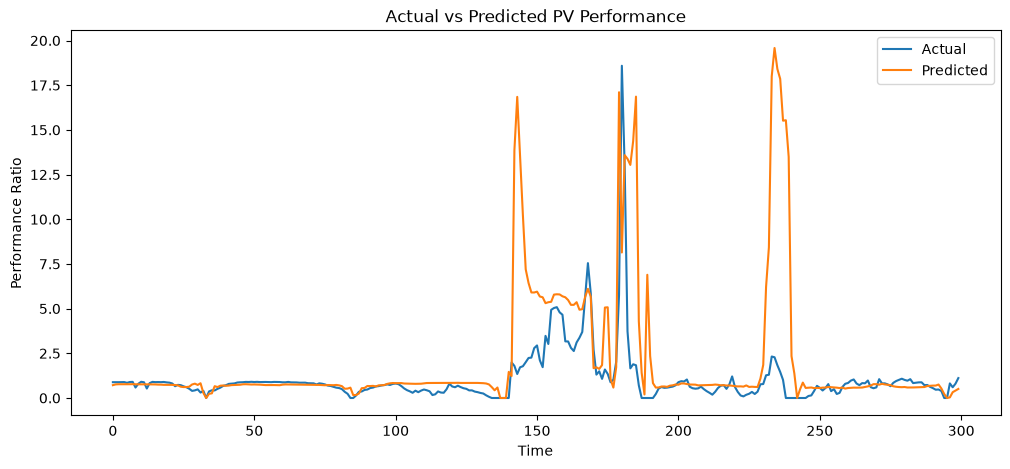

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.iloc[:300].values,
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Performance Ratio")
plt.title("Actual vs Predicted PV Performance")
plt.legend()
plt.show()

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("station07.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (32928, 15)

Columns:
['date_time', 'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure', 'lmd_winddirection', 'lmd_windspeed', 'power']


In [91]:
df.head()

,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power
0,2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,934.799988,168,0.0,0.0
1,2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,934.700012,172,0.0,0.0
2,2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,934.599976,174,0.0,0.0
3,2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,934.599976,173,0.0,0.0
4,2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,934.599976,175,0.0,0.0


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32928 entries, 0 to 32927
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date_time          32928 non-null  str    
 1   nwp_globalirrad    32928 non-null  float64
 2   nwp_directirrad    32928 non-null  float64
 3   nwp_temperature    32928 non-null  float64
 4   nwp_humidity       32928 non-null  float64
 5   nwp_windspeed      32928 non-null  float64
 6   nwp_winddirection  32928 non-null  float64
 7   nwp_pressure       32928 non-null  float64
 8   lmd_totalirrad     32928 non-null  int64  
 9   lmd_diffuseirrad   32928 non-null  int64  
 10  lmd_temperature    32928 non-null  float64
 11  lmd_pressure       32928 non-null  float64
 12  lmd_winddirection  32928 non-null  int64  
 13  lmd_windspeed      32928 non-null  float64
 14  power              32928 non-null  float64
dtypes: float64(11), int64(3), str(1)
memory usage: 4.4 MB


In [93]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nwp_globalirrad,32928.0,160.289396,239.551968,0.00,0.000000,0.000000,275.475000,964.060000
nwp_directirrad,32928.0,140.283026,220.299354,0.00,0.000000,0.000000,231.990000,910.090000
nwp_temperature,32928.0,12.179077,10.680399,-11.64,3.480000,12.330000,21.220000,35.830000
nwp_humidity,32928.0,45.922264,22.790590,4.85,27.470000,41.380000,62.750000,100.000000
nwp_windspeed,32928.0,3.870690,2.098138,0.10,2.450000,3.550000,4.850000,19.090000
nwp_winddirection,32928.0,201.738667,120.487083,0.02,84.450000,220.460000,323.730000,359.990000
nwp_pressure,32928.0,939.949109,7.596273,922.34,932.940000,940.850000,945.150000,960.280000
lmd_totalirrad,32928.0,195.965592,314.079130,0.00,0.000000,18.000000,277.000000,1518.000000
lmd_diffuseirrad,32928.0,71.969479,126.167484,0.00,0.000000,0.000000,91.000000,656.000000
lmd_temperature,32928.0,11.835228,10.892492,-13.80,3.100000,12.000000,20.900000,36.099998


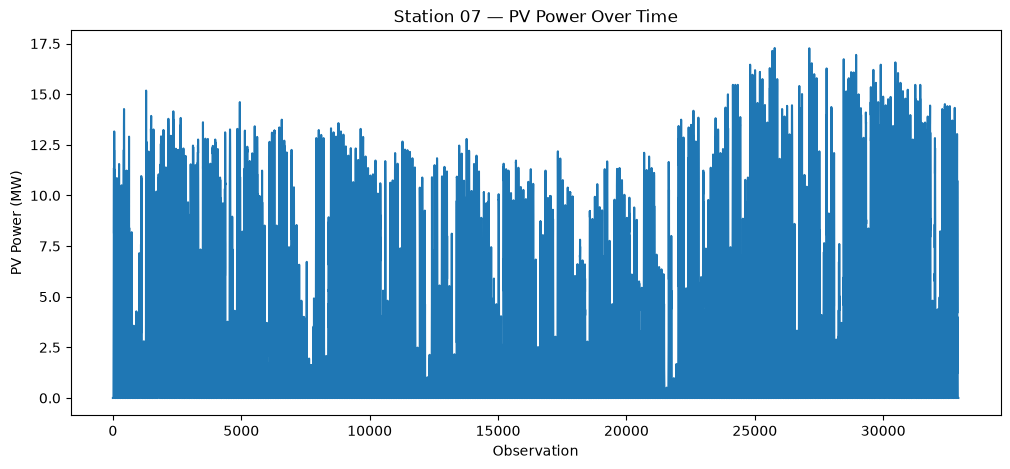

In [95]:
plt.figure(figsize=(12, 5))

plt.plot(df["power"])

plt.xlabel("Observation")
plt.ylabel("PV Power (MW)")
plt.title("Station 07 — PV Power Over Time")

plt.show()

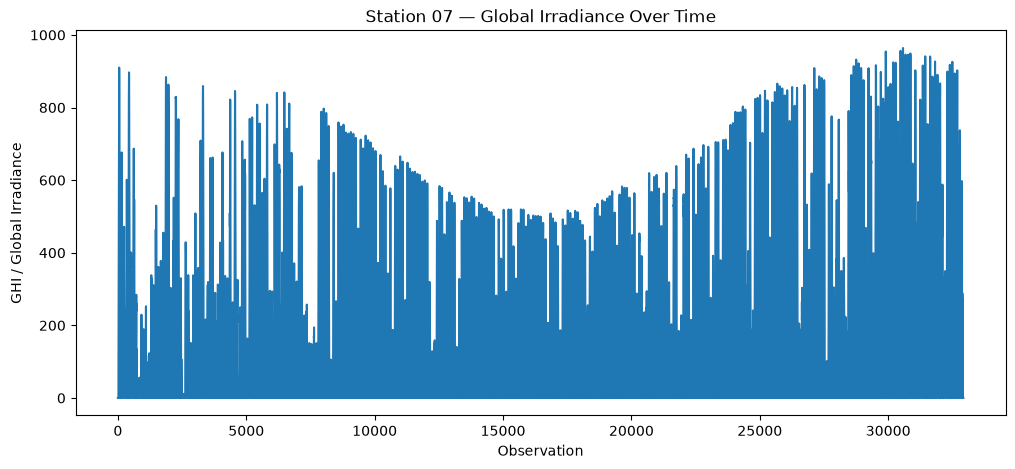

In [96]:
plt.figure(figsize=(12, 5))

plt.plot(df["nwp_globalirrad"])

plt.xlabel("Observation")
plt.ylabel("GHI / Global Irradiance")
plt.title("Station 07 — Global Irradiance Over Time")

plt.show()

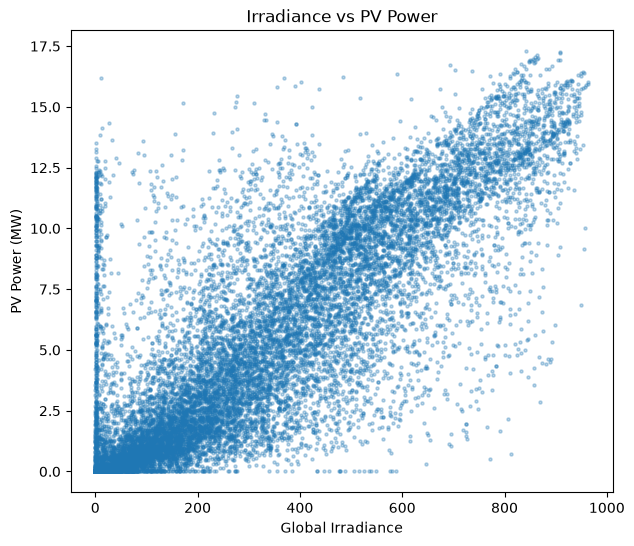

In [97]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df["nwp_globalirrad"],
    df["power"],
    s=5,
    alpha=0.3
)

plt.xlabel("Global Irradiance")
plt.ylabel("PV Power (MW)")
plt.title("Irradiance vs PV Power")

plt.show()

In [98]:
print("Minimum power:", df["power"].min(), "MW")
print("Maximum power:", df["power"].max(), "MW")
print("Mean power:", df["power"].mean(), "MW")

Minimum power: 0.0 MW
Maximum power: 17.280581 MW
Mean power: 2.6185843288994173 MW


In [99]:
print("Minimum GHI:", df["nwp_globalirrad"].min())
print("Maximum GHI:", df["nwp_globalirrad"].max())

Minimum GHI: 0.0
Maximum GHI: 964.06


In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("station07.csv")

print("Shape:", df.shape)

Shape: (32928, 15)


In [101]:
df.loc[
    (df["nwp_globalirrad"] < 10) & (df["power"] > 1),
    ["date_time", "nwp_globalirrad", "nwp_directirrad",
     "nwp_temperature", "nwp_humidity", "power"]
].head(20)

,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,power
533,2018-07-06 05:15:00,3.55,0.00,27.81,58.29,9.706113
534,2018-07-06 05:30:00,3.51,0.00,27.18,61.54,8.412912
535,2018-07-06 05:45:00,2.63,0.00,26.82,63.57,8.768187
536,2018-07-06 06:00:00,2.65,0.00,26.63,64.75,10.402450
827,2018-07-09 06:45:00,6.68,0.00,19.15,84.89,1.733742
828,2018-07-09 07:00:00,8.73,0.00,19.00,86.62,2.714301
1025,2018-07-11 08:15:00,1.20,0.00,26.53,72.65,3.694860
1026,2018-07-11 08:30:00,1.11,0.00,26.39,73.27,5.272281
1097,2018-07-12 02:15:00,5.31,0.00,24.52,85.95,5.698611
1098,2018-07-12 02:30:00,5.52,0.00,24.27,87.78,6.466005


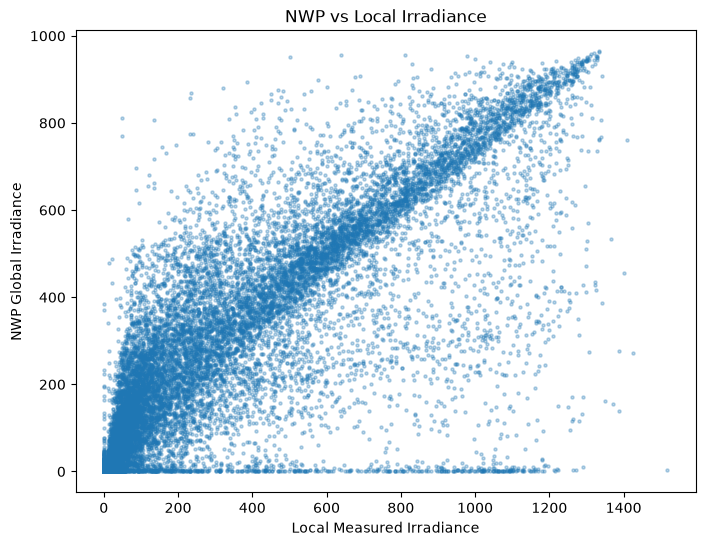

In [102]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["lmd_totalirrad"],
    df["nwp_globalirrad"],
    s=5,
    alpha=0.3
)

plt.xlabel("Local Measured Irradiance")
plt.ylabel("NWP Global Irradiance")
plt.title("NWP vs Local Irradiance")

plt.show()

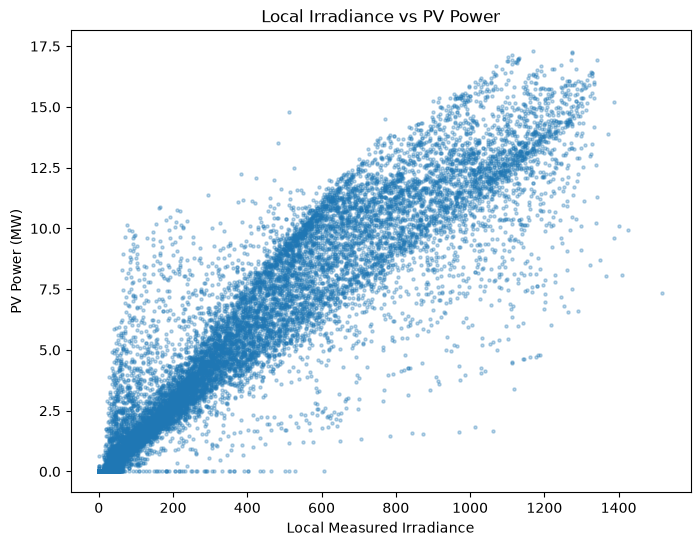

In [103]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["lmd_totalirrad"],
    df["power"],
    s=5,
    alpha=0.3
)

plt.xlabel("Local Measured Irradiance")
plt.ylabel("PV Power (MW)")
plt.title("Local Irradiance vs PV Power")

plt.show()

In [104]:
# Station 07 installed capacity
capacity_mw = 20

# Theoretical output using LOCAL measured irradiance
df["theoretical_power"] = (
    capacity_mw * df["lmd_totalirrad"] / 1000
)

# Only calculate the ratio when there is meaningful irradiance
min_irradiance = 100  # W/m²

df["performance_ratio"] = np.nan

mask = df["lmd_totalirrad"] >= min_irradiance

df.loc[mask, "performance_ratio"] = (
    df.loc[mask, "power"] /
    df.loc[mask, "theoretical_power"]
)

print(df[["lmd_totalirrad", "power",
          "theoretical_power",
          "performance_ratio"]].head(20))

    lmd_totalirrad  power  theoretical_power  performance_ratio
0                0    0.0                0.0                NaN
1                0    0.0                0.0                NaN
2                0    0.0                0.0                NaN
3                0    0.0                0.0                NaN
4                0    0.0                0.0                NaN
5                0    0.0                0.0                NaN
6                0    0.0                0.0                NaN
7                0    0.0                0.0                NaN
8                0    0.0                0.0                NaN
9                0    0.0                0.0                NaN
10               0    0.0                0.0                NaN
11               0    0.0                0.0                NaN
12               0    0.0                0.0                NaN
13               0    0.0                0.0                NaN
14               0    0.0               

In [105]:
print(df["performance_ratio"].describe())

count    11664.000000
mean         0.717533
std          0.279515
min          0.000000
25%          0.584014
50%          0.682742
75%          0.800466
max          4.548913
Name: performance_ratio, dtype: float64


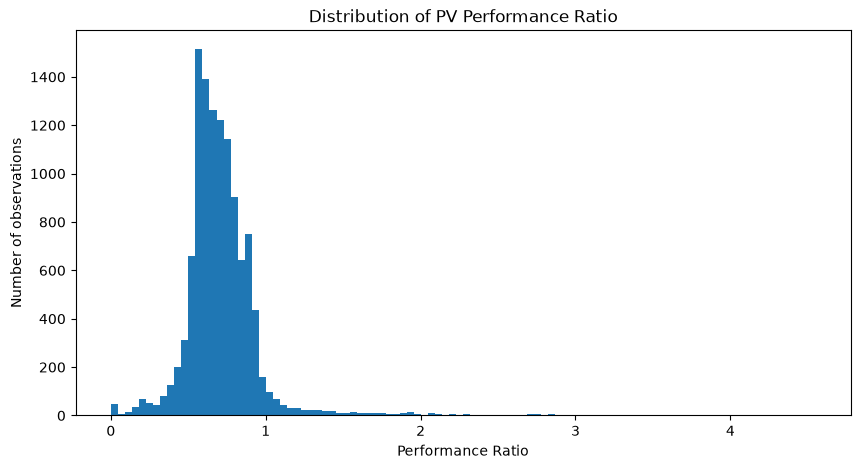

In [106]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["performance_ratio"].dropna(),
    bins=100
)

plt.xlabel("Performance Ratio")
plt.ylabel("Number of observations")
plt.title("Distribution of PV Performance Ratio")

plt.show()

In [107]:
df.loc[
    df["performance_ratio"] > 1.5,
    [
        "date_time",
        "lmd_totalirrad",
        "nwp_globalirrad",
        "power",
        "theoretical_power",
        "performance_ratio"
    ]
].sort_values(
    "performance_ratio",
    ascending=False
).head(20)

,date_time,lmd_totalirrad,nwp_globalirrad,power,theoretical_power,performance_ratio
11482,2018-10-28 06:30:00,102,473.01,9.279783,2.04,4.548913
25217,2019-03-25 08:15:00,101,452.09,8.782398,2.02,4.347722
25697,2019-03-30 08:15:00,104,469.21,8.967141,2.08,4.311125
13499,2018-11-18 06:45:00,102,371.22,8.597655,2.04,4.214537
8989,2018-10-02 07:15:00,104,479.40,8.398701,2.08,4.037837
7934,2018-09-21 07:30:00,105,514.53,8.327646,2.10,3.965546
20986,2019-02-04 06:30:00,129,518.39,9.620847,2.58,3.729010
25698,2019-03-30 08:30:00,107,430.45,7.858683,2.14,3.672282
8695,2018-09-29 05:45:00,123,679.76,8.469756,2.46,3.442990
12632,2018-11-09 06:00:00,145,486.26,9.848223,2.90,3.395939


In [108]:
print("Ratio > 1:", (df["performance_ratio"] > 1).sum())
print("Ratio > 1.5:", (df["performance_ratio"] > 1.5).sum())
print("Ratio > 2:", (df["performance_ratio"] > 2).sum())

Ratio > 1: 602
Ratio > 1.5: 213
Ratio > 2: 103


In [109]:
df.loc[
    df["performance_ratio"] == 0,
    [
        "date_time",
        "lmd_totalirrad",
        "nwp_globalirrad",
        "power",
        "theoretical_power"
    ]
].head(20)

,date_time,lmd_totalirrad,nwp_globalirrad,power,theoretical_power
1398,2018-07-15 05:30:00,511,2.92,0.0,10.22
1399,2018-07-15 05:45:00,304,212.95,0.0,6.08
1400,2018-07-15 06:00:00,149,209.33,0.0,2.98
1401,2018-07-15 06:15:00,390,115.67,0.0,7.80
1402,2018-07-15 06:30:00,402,111.27,0.0,8.04
1403,2018-07-15 06:45:00,265,1.14,0.0,5.30
1404,2018-07-15 07:00:00,528,1.10,0.0,10.56
1405,2018-07-15 07:15:00,433,3.14,0.0,8.66
1406,2018-07-15 07:30:00,205,3.10,0.0,4.10
1407,2018-07-15 07:45:00,216,273.50,0.0,4.32


In [110]:
station07_theoretical = pd.read_csv(
    "station07_theoretical.csv",
    index_col=0,
    parse_dates=True
)

In [111]:
station07_theoretical.head()

,GHI_clear,DNI_clear,DHI_clear,POA_clear,P_theoretical_W
date_time,,,,,
2018-06-30 16:00:00+08:00,637.719883,763.656274,117.181735,582.678207,1.142049e+07
2018-06-30 16:15:00+08:00,592.259620,746.467423,112.787839,529.833736,1.038474e+07
2018-06-30 16:30:00+08:00,544.947697,726.634707,108.048685,475.358157,9.317020e+06
2018-06-30 16:45:00+08:00,496.042406,703.676818,102.937728,418.319316,8.199059e+06
2018-06-30 17:00:00+08:00,445.826639,676.988013,97.417724,361.729905,7.089906e+06


In [112]:
df.index = pd.to_datetime(df.index)

station07_theoretical.index = pd.to_datetime(
    station07_theoretical.index
)

In [113]:
df.index.min()
df.index.max()
len(df)

32928

In [114]:
df.index.min()

Timestamp('1970-01-01 00:00:00')

In [115]:
df.index.max()

Timestamp('1970-01-01 00:00:00.000032927')

In [116]:
len(df)

32928

In [117]:
df.head()


,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power,theoretical_power,performance_ratio
1970-01-01 00:00:00.000000000,2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,934.799988,168,0.0,0.0,0.0,NaN
1970-01-01 00:00:00.000000001,2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,934.700012,172,0.0,0.0,0.0,NaN
1970-01-01 00:00:00.000000002,2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,934.599976,174,0.0,0.0,0.0,NaN
1970-01-01 00:00:00.000000003,2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,934.599976,173,0.0,0.0,0.0,NaN
1970-01-01 00:00:00.000000004,2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,934.599976,175,0.0,0.0,0.0,NaN


In [118]:
df.columns

Index(['date_time', 'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature',
       'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure',
       'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'theoretical_power',
       'performance_ratio'],
      dtype='str')

In [119]:
df.dtypes

date_time                str
nwp_globalirrad      float64
nwp_directirrad      float64
nwp_temperature      float64
nwp_humidity         float64
nwp_windspeed        float64
nwp_winddirection    float64
nwp_pressure         float64
lmd_totalirrad         int64
lmd_diffuseirrad       int64
lmd_temperature      float64
lmd_pressure         float64
lmd_winddirection      int64
lmd_windspeed        float64
power                float64
theoretical_power    float64
performance_ratio    float64
dtype: object

In [120]:
df["date_time"].head(20)

1970-01-01 00:00:00.000000000    2018-06-30 16:00:00
1970-01-01 00:00:00.000000001    2018-06-30 16:15:00
1970-01-01 00:00:00.000000002    2018-06-30 16:30:00
1970-01-01 00:00:00.000000003    2018-06-30 16:45:00
1970-01-01 00:00:00.000000004    2018-06-30 17:00:00
1970-01-01 00:00:00.000000005    2018-06-30 17:15:00
1970-01-01 00:00:00.000000006    2018-06-30 17:30:00
1970-01-01 00:00:00.000000007    2018-06-30 17:45:00
1970-01-01 00:00:00.000000008    2018-06-30 18:00:00
1970-01-01 00:00:00.000000009    2018-06-30 18:15:00
1970-01-01 00:00:00.000000010    2018-06-30 18:30:00
1970-01-01 00:00:00.000000011    2018-06-30 18:45:00
1970-01-01 00:00:00.000000012    2018-06-30 19:00:00
1970-01-01 00:00:00.000000013    2018-06-30 19:15:00
1970-01-01 00:00:00.000000014    2018-06-30 19:30:00
1970-01-01 00:00:00.000000015    2018-06-30 19:45:00
1970-01-01 00:00:00.000000016    2018-06-30 20:00:00
1970-01-01 00:00:00.000000017    2018-06-30 20:15:00
1970-01-01 00:00:00.000000018    2018-06-30 20

In [121]:
df["date_time"] = pd.to_datetime(df["date_time"])

df = df.set_index("date_time")

In [122]:
df.index[:5]

DatetimeIndex(['2018-06-30 16:00:00', '2018-06-30 16:15:00',
               '2018-06-30 16:30:00', '2018-06-30 16:45:00',
               '2018-06-30 17:00:00'],
              dtype='datetime64[us]', name='date_time', freq=None)

In [123]:
print(df.index.min())
print(df.index.max())
print(len(df))

2018-06-30 16:00:00
2019-06-13 15:45:00
32928


In [124]:
times = df.index

In [125]:
print(df.index[:5])
print(df.index.tz)

DatetimeIndex(['2018-06-30 16:00:00', '2018-06-30 16:15:00',
               '2018-06-30 16:30:00', '2018-06-30 16:45:00',
               '2018-06-30 17:00:00'],
              dtype='datetime64[us]', name='date_time', freq=None)
None


In [127]:
pd.DataFrame(index=df.index).to_csv(
    "station07_timestamps.csv"
)

In [128]:
station07_theoretical = pd.read_csv(
    "station07_theoretical.csv",
    index_col=0,
    parse_dates=True
)

In [129]:
print("Data timezone:", df.index.tz)
print("Theoretical timezone:", station07_theoretical.index.tz)

Data timezone: Asia/Shanghai
Theoretical timezone: UTC+08:00


In [130]:
print(df.index[0])
print(station07_theoretical.index[0])

print(df.index[-1])
print(station07_theoretical.index[-1])

print(df.index.equals(station07_theoretical.index))

2018-06-30 16:00:00+08:00
2018-06-30 16:00:00+08:00
2019-06-13 15:45:00+08:00
2019-06-13 15:45:00+08:00
False


In [131]:
print("Data rows:", len(df))
print("Theoretical rows:", len(station07_theoretical))

print("Data duplicated timestamps:",
      df.index.duplicated().sum())

print("Theoretical duplicated timestamps:",
      station07_theoretical.index.duplicated().sum())

Data rows: 32928
Theoretical rows: 32928
Data duplicated timestamps: 0
Theoretical duplicated timestamps: 0


In [132]:
missing_from_theoretical = df.index.difference(
    station07_theoretical.index
)

missing_from_data = station07_theoretical.index.difference(
    df.index
)

print("In data but NOT theoretical:", len(missing_from_theoretical))
print("In theoretical but NOT data:", len(missing_from_data))

In data but NOT theoretical: 0
In theoretical but NOT data: 0


In [133]:
print(missing_from_theoretical[:20])
print(missing_from_data[:20])

DatetimeIndex([], dtype='datetime64[us, Asia/Shanghai]', name='date_time', freq=None)
DatetimeIndex([], dtype='datetime64[us, UTC+08:00]', name='date_time', freq=None)


In [134]:
df = df.join(
    station07_theoretical,
    how="left"
)

In [135]:
df[[
    "power",
    "P_theoretical_W"
]].head(20)

,power,P_theoretical_W
date_time,,
2018-06-30 08:00:00+00:00,0.0,1.142049e+07
2018-06-30 08:15:00+00:00,0.0,1.038474e+07
2018-06-30 08:30:00+00:00,0.0,9.317020e+06
2018-06-30 08:45:00+00:00,0.0,8.199059e+06
2018-06-30 09:00:00+00:00,0.0,7.089906e+06
2018-06-30 09:15:00+00:00,0.0,5.980558e+06
2018-06-30 09:30:00+00:00,0.0,4.885351e+06
2018-06-30 09:45:00+00:00,0.0,3.821683e+06
2018-06-30 10:00:00+00:00,0.0,2.811157e+06


In [136]:
print(
    "Missing theoretical values:",
    df["P_theoretical_W"].isna().sum()
)

Missing theoretical values: 0


In [137]:
df["K_PV"] = np.where(
    df["P_theoretical_W"] > 0,
    df["power"] / df["P_theoretical_W"],
    np.nan
)

In [138]:
df[[
    "power",
    "P_theoretical_W",
    "K_PV"
]].head(30)

,power,P_theoretical_W,K_PV
date_time,,,
2018-06-30 08:00:00+00:00,0.000000,1.142049e+07,0.0
2018-06-30 08:15:00+00:00,0.000000,1.038474e+07,0.0
2018-06-30 08:30:00+00:00,0.000000,9.317020e+06,0.0
2018-06-30 08:45:00+00:00,0.000000,8.199059e+06,0.0
2018-06-30 09:00:00+00:00,0.000000,7.089906e+06,0.0
2018-06-30 09:15:00+00:00,0.000000,5.980558e+06,0.0
2018-06-30 09:30:00+00:00,0.000000,4.885351e+06,0.0
2018-06-30 09:45:00+00:00,0.000000,3.821683e+06,0.0
2018-06-30 10:00:00+00:00,0.000000,2.811157e+06,0.0


In [139]:
df["K_PV"].describe()

count    1.648600e+04
mean     1.677561e-04
std      5.674099e-03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.639077e-08
max      4.112450e-01
Name: K_PV, dtype: float64

In [140]:
print(df["power"].describe())

count    32928.000000
mean         2.618584
std          4.106109
min          0.000000
25%          0.000000
50%          0.000000
75%          4.206456
max         17.280581
Name: power, dtype: float64


In [141]:
print(df[["power", "P_theoretical_W"]].tail(20))

                           power  P_theoretical_W
date_time                                        
2019-06-13 03:00:00+00:00    0.0     1.797109e+07
2019-06-13 03:15:00+00:00    0.0     1.840517e+07
2019-06-13 03:30:00+00:00    0.0     1.875715e+07
2019-06-13 03:45:00+00:00    0.0     1.902572e+07
2019-06-13 04:00:00+00:00    0.0     1.921019e+07
2019-06-13 04:15:00+00:00    0.0     1.931043e+07
2019-06-13 04:30:00+00:00    0.0     1.932662e+07
2019-06-13 04:45:00+00:00    0.0     1.925879e+07
2019-06-13 05:00:00+00:00    0.0     1.910680e+07
2019-06-13 05:15:00+00:00    0.0     1.887062e+07
2019-06-13 05:30:00+00:00    0.0     1.855069e+07
2019-06-13 05:45:00+00:00    0.0     1.814809e+07
2019-06-13 06:00:00+00:00    0.0     1.766454e+07
2019-06-13 06:15:00+00:00    0.0     1.710237e+07
2019-06-13 06:30:00+00:00    0.0     1.646448e+07
2019-06-13 06:45:00+00:00    0.0     1.575429e+07
2019-06-13 07:00:00+00:00    0.0     1.497576e+07
2019-06-13 07:15:00+00:00    0.0     1.419747e+07


In [144]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.set_index("date_time")

In [145]:
print(df.index[:5])
print(df.index.tz)

DatetimeIndex(['2018-06-30 16:00:00', '2018-06-30 16:15:00',
               '2018-06-30 16:30:00', '2018-06-30 16:45:00',
               '2018-06-30 17:00:00'],
              dtype='datetime64[us]', name='date_time', freq=None)
None


In [146]:
times = df.index.tz_localize("UTC")

In [147]:
pd.DataFrame(
    {"date_time": df.index}
).to_csv("station07_timestamps.csv", index=False)